In [1]:
# Q.1
import pandas as pd
df = pd.read_csv("heart.csv")
print("First 10 Rows:")
print(df.head(10))
print("\nShape of Dataset:")
print(df.shape)
print("\nDataset Information:")
df.info()

First 10 Rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up        

In [2]:
#Q.2)
print("Missing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [3]:
# Q.3

duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

df = df.drop_duplicates()

print("New Shape after Removing Duplicates:")
print(df.shape)

Duplicate Rows: 0
New Shape after Removing Duplicates:
(918, 12)


In [4]:
# Q.4

chol_zero = (df["Cholesterol"] == 0).sum()
bp_zero = (df["RestingBP"] == 0).sum()

print("Rows with Cholesterol = 0:", chol_zero)
print("Rows with RestingBP = 0:", bp_zero)


Rows with Cholesterol = 0: 172
Rows with RestingBP = 0: 1


In [6]:
# Q.5

print("Before Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

chol_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()
bp_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()

df["Cholesterol"] = df["Cholesterol"].astype(float)
df["RestingBP"] = df["RestingBP"].astype(float)
df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

print("\nAfter Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

Before Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


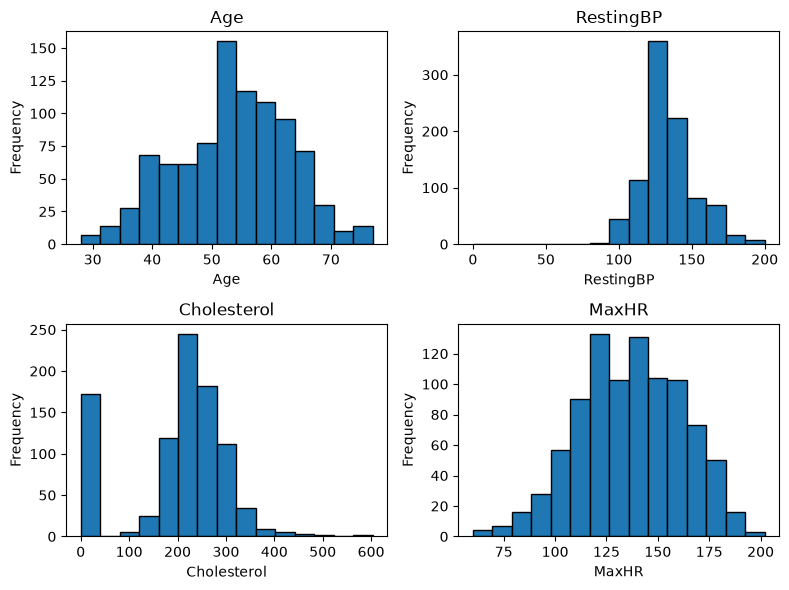

In [8]:
# Q.6

import matplotlib.pyplot as plt

def plot_histograms(data):
    columns = ["Age", "RestingBP", "Cholesterol", "MaxHR"]

    plt.figure(figsize=(8, 6))

    for i, col in enumerate(columns, 1):
        plt.subplot(2, 2, i)
        plt.hist(data[col], bins=15, edgecolor="black")
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

plot_histograms(df)

In [9]:
# Q.7

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(list(num_cols))

print("\nCategorical Columns:")
print(list(cat_cols))

Numerical Columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Categorical Columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


C:\Users\HP\AppData\Local\Temp\ipykernel_26580\3194912438.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [10]:
# Q.8

df_encoded = pd.get_dummies(df, columns=cat_cols)

print("Shape of Encoded Dataset:")
print(df_encoded.shape)

print("\nFirst 5 Rows:")
print(df_encoded.head())

Shape of Encoded Dataset:
(918, 21)

First 5 Rows:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LVH

In [11]:
# Q.9

print("Final Shape:")
print(df_encoded.shape)

print("\nColumn Names:")
print(df_encoded.columns.tolist())

Final Shape:
(918, 21)

Column Names:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [12]:
# Q.10

print("Summary:")
print("- The dataset was loaded and explored successfully.")
print("- Duplicate rows were identified and removed.")
print("- Missing values represented by 0 in Cholesterol and RestingBP were replaced with their mean values.")
print("- Histograms were plotted to visualize the distribution of numerical features.")
print("- Numerical and categorical columns were identified.")
print("- Categorical columns were converted into numerical form using one-hot encoding.")
print("- The dataset is now clean and ready for machine learning or further data analysis.")

Summary:
- The dataset was loaded and explored successfully.
- Duplicate rows were identified and removed.
- Missing values represented by 0 in Cholesterol and RestingBP were replaced with their mean values.
- Histograms were plotted to visualize the distribution of numerical features.
- Numerical and categorical columns were identified.
- Categorical columns were converted into numerical form using one-hot encoding.
- The dataset is now clean and ready for machine learning or further data analysis.
